# Mestrado em Inteligência Artificial 25/26

# Practical 2 - Markov Decision Processes (MDPs) with Gridworld - Solutions

What's the optimal behaviour?

> The optimal behaviour is to reach a terminal in as few steps as possible.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Dict, Tuple, List, Optional

np.set_printoptions(precision=3, suppress=True)

## 1) Gridworld MDP

We define:
- **States**: cells \((r,c)\)
- **Actions**: `U, D, L, R`
- **Transition**: deterministic (attempted move; if off-grid you stay)
- **Reward**: -1 each step; terminal states end the episode

We will implement an `env.step(state, action)` that returns:
`next_state, reward, done_flag`

In [ ]:
ACTIONS = ["U", "D", "L", "R"]
ACTION_TO_DELTA = {
    "U": (-1, 0),
    "D": ( 1, 0),
    "L": ( 0,-1),
    "R": ( 0, 1),
}

@dataclass(frozen=True)
class Gridworld:
    n_rows: int = 4
    n_cols: int = 4
    terminal_states: Tuple[Tuple[int,int], ...] = ((0,0), (3,3))
    step_reward: float = -1.0

    def states(self) -> List[Tuple[int,int]]:
        return [(r,c) for r in range(self.n_rows) for c in range(self.n_cols)]

    def is_terminal(self, state: Tuple[int,int]) -> bool:
        return state in self.terminal_states

    def step(self, state: Tuple[int,int], action: str) -> Tuple[Tuple[int,int], float, bool]:
        if self.is_terminal(state):
            return state, 0.0, True  # terminal state

        # TODO 1: define the step

        #--- YOUR CODE STARTS HERE ---
        d_row, d_col = ACTION_TO_DELTA[action]
        next_row, next_col = state[0] + d_row, state[1] + d_col

        # bump into wall => stay
        if next_row < 0 or next_row >= self.n_rows or next_col < 0 or next_col >= self.n_cols:
            next_state = state
        else:
            next_state = (next_row, next_col)

        reward = self.step_reward
        done_flag = self.is_terminal(next_state)
        # --- YOUR CODE ENDS HERE ---

        return next_state, reward, done_flag

env = Gridworld()
env.states()[:5], env.terminal_states

([(0, 0), (0, 1), (0, 2), (0, 3), (1, 0)], ((0, 0), (3, 3)))

### Quick sanity checks

In [ ]:
# From a non-terminal, moving into a wall keeps you in place but still costs -1
print("From (0,1) with U:", env.step((0,1), "U"))
# From a non-terminal, moving toward terminal
print("From (0,1) with L:", env.step((0,1), "L"))
# From terminal, stay terminal
print("From (0,0) with R:", env.step((0,0), "R"))

From (0,1) with U: ((0, 1), -1.0, False)
From (0,1) with L: ((0, 0), -1.0, True)
From (0,0) with R: ((0, 0), 0.0, True)


## 2) Utilities: indexing states and initializing V

We'll store $V$ as a 2D array `V[r,c]`.

In [ ]:
def zeros_V(env: Gridworld) -> np.ndarray:
    return np.zeros((env.n_rows, env.n_cols), dtype=float)

def all_states(env: Gridworld) -> List[Tuple[int,int]]:
    return env.states()


ARROW = {"U":"↑", "D":"↓", "L":"←", "R":"→", "·":"·"}

def plot_grid_values_and_policy(
    env: Gridworld,
    V: np.ndarray,
    policy: Optional[Dict[Tuple[int,int], str]] = None,
    title: str = "",
    value_fmt: str = "{:.2f}",
):
    fig, ax = plt.subplots(figsize=(6,6))
    ax.set_title(title)

    # draw grid lines
    ax.set_xlim(0, env.n_cols)
    ax.set_ylim(0, env.n_rows)
    ax.set_xticks(np.arange(env.n_cols+1))
    ax.set_yticks(np.arange(env.n_rows+1))
    ax.grid(True)
    ax.invert_yaxis()  # row 0 at top
    ax.set_xticklabels([])
    ax.set_yticklabels([])

    # highlight terminal states
    for (r,c) in env.terminal_states:
        rect = plt.Rectangle((c, r), 1, 1, fill=True, alpha=0.15)
        ax.add_patch(rect)

    # put values + arrows
    for r in range(env.n_rows):
        for c in range(env.n_cols):
            s = (r,c)
            v = V[r,c]
            txt = value_fmt.format(v)
            ax.text(c+0.5, r+0.45, txt, ha="center", va="center", fontsize=12)
            if policy is not None:
                a = policy[s] if s in policy else "·"
                ax.text(c+0.5, r+0.78, ARROW.get(a,"·"), ha="center", va="center", fontsize=18)

    plt.show()


V0 = zeros_V(env)
V0

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 3) Policy definition

We start with a **uniform random policy**:
$\pi(a\mid s)=\frac{1}{4}$ for all non-terminal states.

In [ ]:
def uniform_random_policy(env: Gridworld) -> Dict[Tuple[int,int], Dict[str, float]]:
    policy = {}
    for s in env.states():
        if env.is_terminal(s):
            policy[s] = {a: 0.0 for a in ACTIONS}
        else:
            policy[s] = {a: 1.0/len(ACTIONS) for a in ACTIONS}
    return policy

policy = uniform_random_policy(env)
policy[(1,1)]

{'U': 0.25, 'D': 0.25, 'L': 0.25, 'R': 0.25}

## 4) Policy Evaluation (compute $V^{\pi}$)

Bellman expectation backup:

$
V(s) \leftarrow \sum_a \pi(a|s)\left[r(s,a) + \gamma V(s')\right]
$

### ✅ Your task
Fill in the two TODOs:
1. Compute the expected update for a single state (`bellman_expectation_update`)
2. Run iterative policy evaluation (`policy_evaluation`)

In [ ]:
def bellman_expectation_update(
    env: Gridworld, V: np.ndarray, policy: Dict[Tuple[int,int], Dict[str,float]],
    state: Tuple[int,int], gamma: float
) -> float:
    """Return the updated V(s) using the Bellman expectation backup."""
    if env.is_terminal(state):
        return 0.0

    # TODO 2: compute expected value over actions under pi(a|s)y alternating between evaluati
    # Hints:
    #  - loop over actions
    #  - env.step(s,a) gives (s', r, done)
    #  - use V[s'] (i.e., V[nr,nc])
    v_new = 0.0
    # --- YOUR CODE STARTS HERE ---
    for a, p in policy[state].items():
        ns, r, done = env.step(state, a)
        v_new += p * (r + gamma * V[ns[0], ns[1]])
    # --- YOUR CODE ENDS HERE ---
    return v_new


def policy_evaluation(
    env: Gridworld,
    policy: Dict[Tuple[int,int], Dict[str,float]],
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    """Iterative policy evaluation."""
    V = zeros_V(env)

    for it in range(max_iters):
        delta = 0.0

        # TODO 3: sweep all states and update V in-place (or into a copy)
        # Use delta = max(delta, |V_new - V_old|). Stop if delta < theta.
        # --- YOUR CODE STARTS HERE ---
        V_old = V.copy()
        for state in env.states():
            v_new = bellman_expectation_update(env, V_old, policy, state, gamma)
            delta = max(delta, abs(v_new - V[state[0], state[1]]))
            V[state[0], state[1]] = v_new
        # --- YOUR CODE ENDS HERE ---

        if delta < theta:
            return V, it + 1

    return V, max_iters

In [ ]:
gamma = 0.9
V_pi, iters = policy_evaluation(env, policy, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters)
V_pi

Converged in iterations: 118


array([[ 0.   , -5.278, -7.128, -7.651],
       [-5.278, -6.606, -7.181, -7.128],
       [-7.128, -7.181, -6.606, -5.278],
       [-7.651, -7.128, -5.278,  0.   ]])

In [ ]:
def policy_evaluation_with_history(
    env: Gridworld,
    policy: Dict[Tuple[int,int], Dict[str,float]],
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[List[np.ndarray], List[int]]:
    V = zeros_V(env)
    V_history = [V.copy()]
    iters_history = [0]

    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()
        for state in env.states():
            v_new = bellman_expectation_update(env, V_old, policy, state, gamma)
            delta = max(delta, abs(v_new - V[state[0], state[1]]))
            V[state[0], state[1]] = v_new
        V_history.append(V.copy())
        iters_history.append(it + 1)
        if delta < theta:
            return V_history, iters_history

    return V_history, max_iters

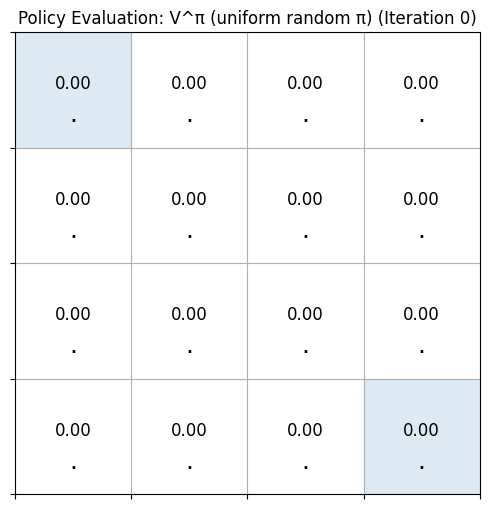

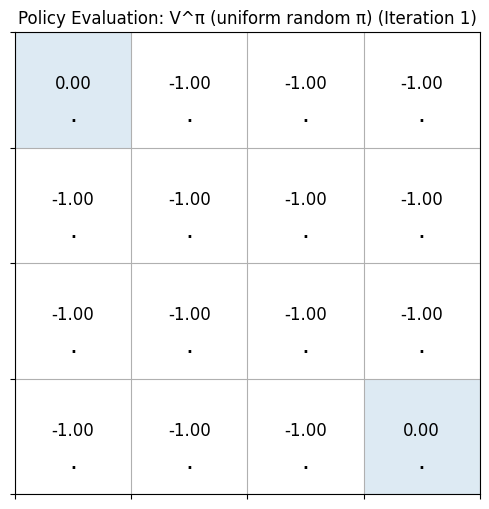

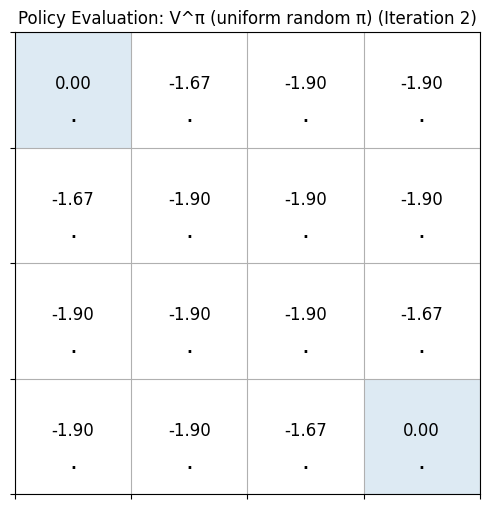

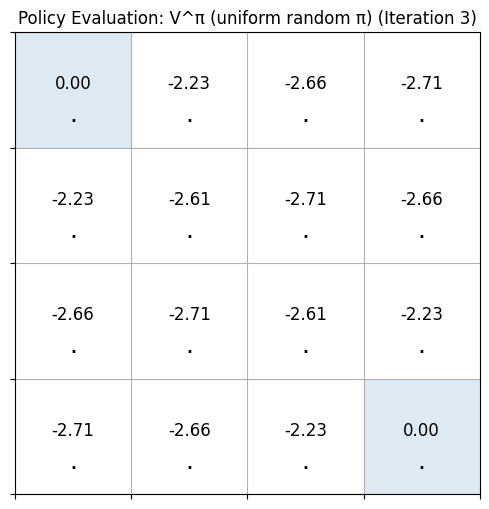

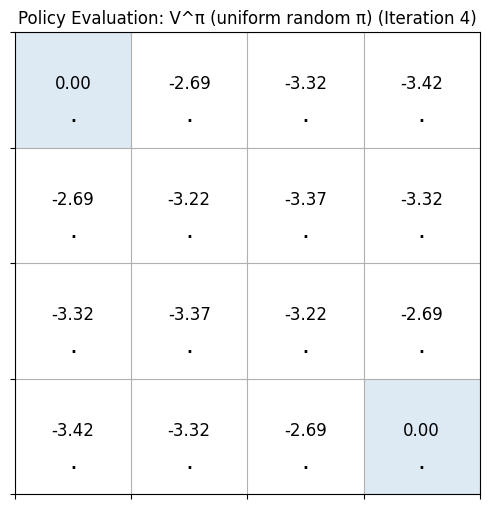

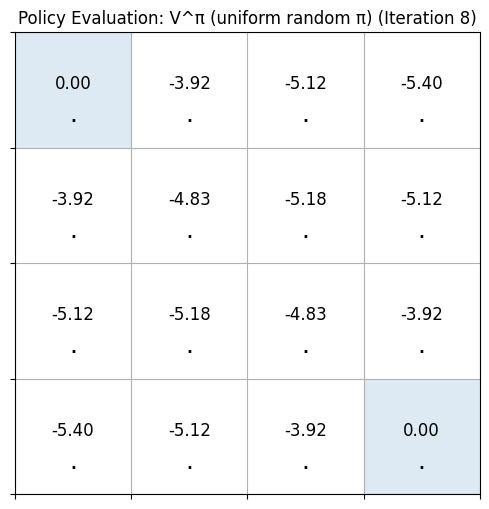

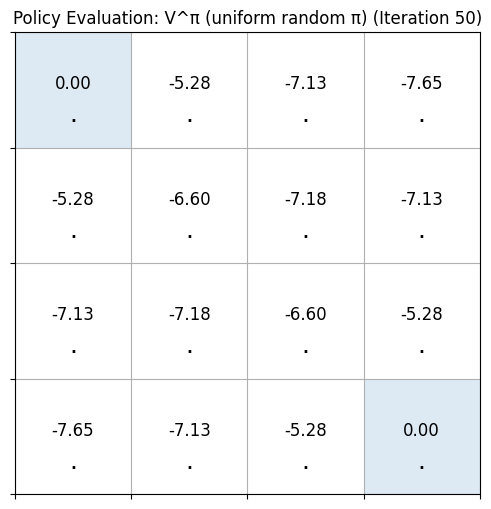

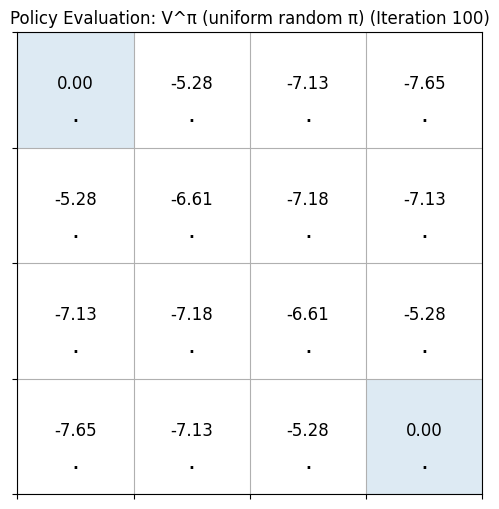

In [ ]:
V_pi_hist, it_pi_hist = policy_evaluation_with_history(env, policy, gamma=gamma, theta=1e-8)

# For policy evaluation, the policy is fixed (uniform random), so we don't need to derive it from V.
# However, the plot_grid_values_and_policy expects a single action per state for arrows.
# For a uniform random policy, we can choose not to show arrows or represent them as '·'.
# Let's create a placeholder policy that always shows '·' for non-terminal states.
plot_policy_for_pe = {
    s: '·' if env.is_terminal(s) else '?' for s in env.states()
}

# User-requested specific iterations to plot
specific_iterations = [0, 1, 2, 3, 4, 8, 50, 100]

# Filter out iterations that are beyond the actual history length
indices_to_plot = sorted(list(set([it for it in specific_iterations if it < len(V_pi_hist)])))

for i in indices_to_plot:
    current_V_pi = V_pi_hist[i]
    current_it_pi = it_pi_hist[i]
    plot_grid_values_and_policy(
        env, current_V_pi, plot_policy_for_pe,
        title=f"Policy Evaluation: V^π (uniform random π) (Iteration {current_it_pi})"
    )

## 5) Value Iteration (approximate $V^{*}$)

Bellman optimality backup:

$
V(s) \leftarrow \max_a \left[r(s,a) + \gamma V(s')\right]
$

We then extract a greedy policy:
$\pi(s)=\arg\max_a\,[r(s,a)+\gamma V(s')]$

In [ ]:
def bellman_optimality_update(env: Gridworld, V: np.ndarray, s: Tuple[int,int], gamma: float) -> float:
    if env.is_terminal(s):
        return 0.0
    best = -np.inf
    for a in ACTIONS:
        ns, r, done = env.step(s, a)
        best = max(best, r + gamma * V[ns[0], ns[1]])
    return best

def value_iteration(
    env: Gridworld,
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    V = zeros_V(env)
    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()
        for s in env.states():
            v_new = bellman_optimality_update(env, V_old, s, gamma)
            delta = max(delta, abs(v_new - V[s[0], s[1]]))
            V[s[0], s[1]] = v_new
        if delta < theta:
            return V, it + 1
    return V, max_iters

V_star, iters_vi = value_iteration(env, gamma=gamma, theta=1e-8)
print("Converged in iterations:", iters_vi)
V_star

Converged in iterations: 4


array([[ 0.  , -1.  , -1.9 , -2.71],
       [-1.  , -1.9 , -2.71, -1.9 ],
       [-1.9 , -2.71, -1.9 , -1.  ],
       [-2.71, -1.9 , -1.  ,  0.  ]])

In [ ]:
def greedy_policy_from_V(env: Gridworld, V: np.ndarray, gamma: float) -> Dict[Tuple[int,int], str]:
    pi_greedy = {}
    for s in env.states():
        if env.is_terminal(s):
            pi_greedy[s] = "·"
            continue

        # TODO 4: get the best 'a' and 'q'
        # --- YOUR CODE STARTS HERE ---
        best_a = None
        best_q = -np.inf
        for a in ACTIONS:
            ns, r, done = env.step(s, a)
            q = r + gamma * V[ns[0], ns[1]]
            if q > best_q:
                best_q = q
                best_a = a
        pi_greedy[s] = best_a

        # --- YOUR CODE ENDS HERE ---
    return pi_greedy

pi_star = greedy_policy_from_V(env, V_star, gamma=gamma)
pi_star[(2,2)], pi_star[(0,1)], pi_star[(1,0)]

('D', 'L', 'U')

In [ ]:
pi_star

{(0, 0): '·',
 (0, 1): 'L',
 (0, 2): 'L',
 (0, 3): 'D',
 (1, 0): 'U',
 (1, 1): 'U',
 (1, 2): 'U',
 (1, 3): 'D',
 (2, 0): 'U',
 (2, 1): 'U',
 (2, 2): 'D',
 (2, 3): 'D',
 (3, 0): 'U',
 (3, 1): 'R',
 (3, 2): 'R',
 (3, 3): '·'}

## 5.5) Compute the action-value function $Q^{\pi}$

So far, we computed **state-value functions**.
We now introduce the **action-value function**.

For a deterministic environment, the Bellman expectation equation for $Q^{\pi}$ is:

$$
Q^{\pi}(s,a) = r(s,a) + \gamma \sum_{a'} \pi(a'\mid s')\,Q^{\pi}(s',a')
$$

where $(s', r, done) = \texttt{step}(s,a)$.

We'll implement **iterative evaluation of $Q^{\pi}$** and verify:

$$
V^{\pi}(s) = \sum_a \pi(a\mid s)\,Q^{\pi}(s,a)
$$

In [ ]:
def zeros_Q(env: Gridworld) -> np.ndarray:
    # Q[r,c,a_index]
    return np.zeros((env.n_rows, env.n_cols, len(ACTIONS)), dtype=float)

def policy_evaluation_Q(
    env: Gridworld,
    pi: Dict[Tuple[int,int], Dict[str,float]],
    gamma: float,
    theta: float = 1e-6,
    max_iters: int = 10_000,
) -> Tuple[np.ndarray, int]:
    Q = zeros_Q(env)

    for it in range(max_iters):
        delta = 0.0
        Q_old = Q.copy()

        for (r,c) in env.states():
            s = (r,c)
            if env.is_terminal(s):
                Q[r,c,:] = 0.0
                continue

            for a_index, a in enumerate(ACTIONS):
                ns, reward, done = env.step(s, a)
                nr, nc = ns

                # Expected over next action under pi
                exp_next = 0.0
                for aj, a2 in enumerate(ACTIONS):
                    exp_next += pi[ns][a2] * Q_old[nr, nc, aj]

                q_new = reward + gamma * exp_next
                delta = max(delta, abs(q_new - Q[r,c,a_index]))
                Q[r,c,a_index] = q_new

        if delta < theta:
            return Q, it + 1

    return Q, max_iters

Q_pi, itq = policy_evaluation_Q(env, policy, gamma=gamma, theta=1e-8)
print("Q^pi converged in iterations:", itq)

# Verify V^pi(s) = sum_a pi(a|s) Q^pi(s,a)
V_from_Q = zeros_V(env)
for (r,c) in env.states():
    s = (r,c)
    if env.is_terminal(s):
        V_from_Q[r,c] = 0.0
    else:
        V_from_Q[r,c] = sum(policy[s][a]*Q_pi[r,c,a_index] for a_index,a in enumerate(ACTIONS))

print("max |V_pi - V_from_Q| =", np.max(np.abs(V_pi - V_from_Q)))

Q^pi converged in iterations: 118
max |V_pi - V_from_Q| = 0.0


## 6) Visualization

We will visualize:
- The value function as numbers inside the grid
- A policy as arrows

This is the part that makes Bellman backups “click”.

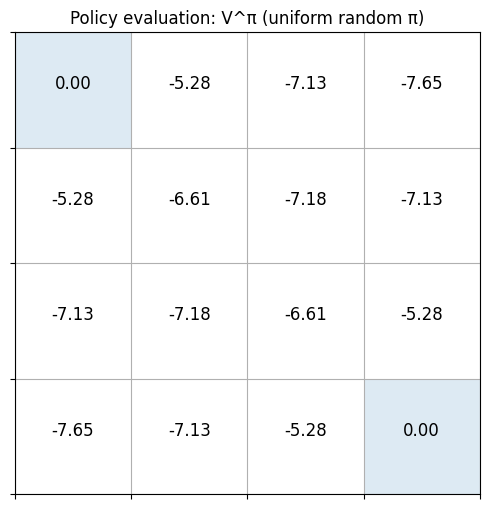

In [ ]:
plot_grid_values_and_policy(env, V_pi, None, title="Policy evaluation: V^π (uniform random π)")

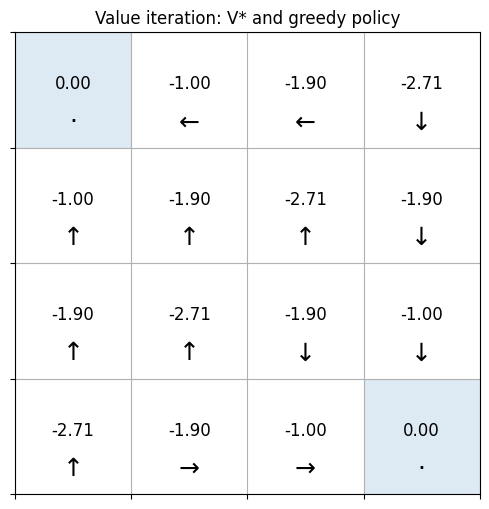

In [ ]:
plot_grid_values_and_policy(env, V_star, pi_star, title="Value iteration: V* and greedy policy")

Given that both terminal states are equally far from (3,0) and (0,3), why does the optimal policy move vertically rather than horizontally in those states?

## 7) Exercises

### Exercise A — Change $\gamma$ and observe
Try `gamma = 0.5` and `gamma = 0.99`. Re-run policy evaluation and value iteration.
What changes in the value magnitude and the implied behaviour?

### Exercise B — Add a “trap” cell
Pick a cell, e.g. (1,2), and make stepping *into* it give reward -10.
How does the optimal policy change? Tip: Inherit from the Gridworld class

### Exercise C — Make the environment stochastic
Modify `env.step` so that with probability 0.8 the intended action happens, and with probability 0.1 you slip left/right (relative to intended direction).
What changes in $V^{*}$ and the greedy policy?



## 8) Solutions to the Exercises

### Exercise A — Changing $\gamma$
- Smaller $\gamma$ (e.g., 0.5): the agent values the future less, so **magnitudes shrink** (less negative far away).
  The *direction* of the optimal policy is usually unchanged here (still “shortest path”), but values drop off faster.
- Larger $\gamma$ (e.g., 0.99): the agent values long-term rewards more, so **magnitudes grow** (more negative far away),
  because it effectively “counts” many future step costs.

### Exercise B — Trap cell with -10 on entry
The optimal policy will tend to **route around** the trap, even if that takes extra steps, depending on $\gamma$.
With high $\gamma$, avoiding the trap is even more important.

### Exercise C — Stochastic slip
Adding slip makes outcomes uncertain. Values typically become **more negative** (mistakes cost steps).
The optimal policy may become more “cautious” near terminals or traps to reduce the chance of slipping into bad states.




Gamma = 0.5 (value iteration iters=4)


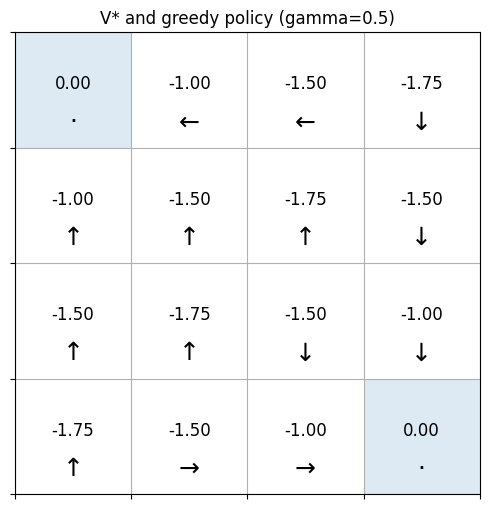


Gamma = 0.9 (value iteration iters=4)


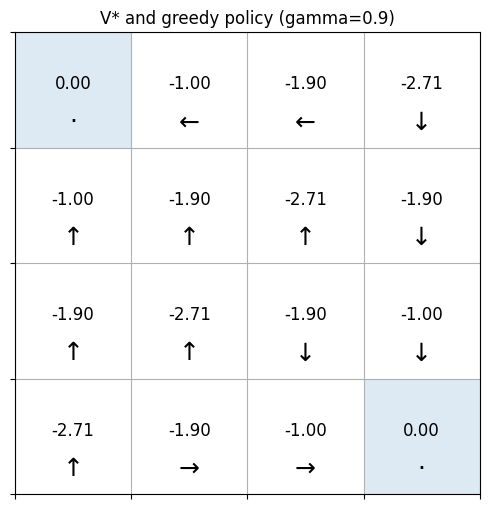


Gamma = 0.99 (value iteration iters=4)


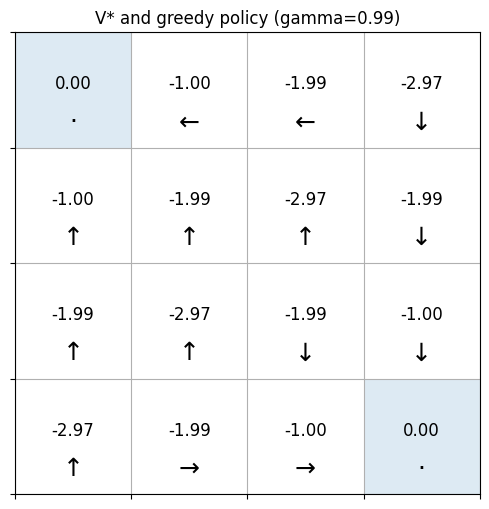

In [ ]:
# Exercise A: compare gammas
for g in [0.5, 0.9, 0.99]:
    Vg, itg = value_iteration(env, gamma=g, theta=1e-8)
    pig = greedy_policy_from_V(env, Vg, gamma=g)
    print(f"\nGamma = {g} (value iteration iters={itg})")
    plot_grid_values_and_policy(env, Vg, pig, title=f"V* and greedy policy (gamma={g})")

Trap value iteration iters: 4


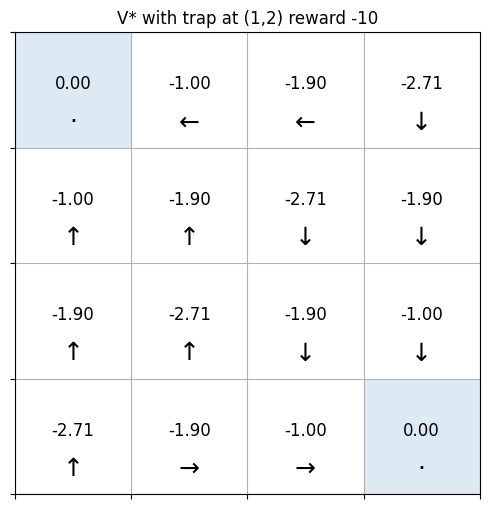

In [ ]:
# Exercise B: trap cell with -10 on entry
trap = (0,2)

class TrapGridworld(Gridworld):
    def step(self, s: Tuple[int,int], a: str):
        ns, r, done = super().step(s, a)
        if (not self.is_terminal(s)) and ns == trap:
            r = -10.0
        return ns, r, done

env_trap = TrapGridworld()
V_trap, it_trap = value_iteration(env_trap, gamma=0.90, theta=1e-8)
pi_trap = greedy_policy_from_V(env_trap, V_trap, gamma=0.90)
print("Trap value iteration iters:", it_trap)
plot_grid_values_and_policy(env_trap, V_trap, pi_trap, title="V* with trap at (1,2) reward -10")

Stochastic value iteration iters: 25


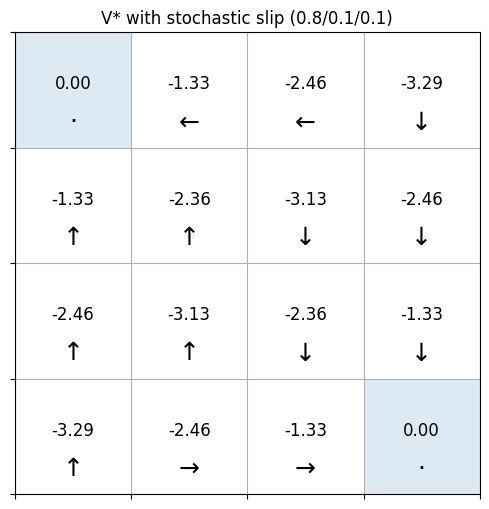

In [ ]:
# Exercise C: stochastic slip (0.8 intended, 0.1 left/right) solved via expected backups
LEFT_OF = {"U":"L","D":"R","L":"D","R":"U"}
RIGHT_OF = {"U":"R","D":"L","L":"U","R":"D"}

def expected_backup_optimal_stochastic(env: Gridworld, V: np.ndarray, s: Tuple[int,int], a: str, gamma: float) -> float:
    if env.is_terminal(s):
        return 0.0
    outcomes = [(a, 0.8), (LEFT_OF[a], 0.1), (RIGHT_OF[a], 0.1)]
    exp = 0.0
    for a_eff, p in outcomes:
        ns, r, done = env.step(s, a_eff)
        exp += p * (r + gamma * V[ns[0], ns[1]])
    return exp

def value_iteration_stochastic(env: Gridworld, gamma: float, theta: float=1e-6, max_iters: int=10_000):
    V = zeros_V(env)
    for it in range(max_iters):
        delta = 0.0
        V_old = V.copy()
        for s in env.states():
            if env.is_terminal(s):
                V[s[0], s[1]] = 0.0
                continue
            best = -np.inf
            for a in ACTIONS:
                best = max(best, expected_backup_optimal_stochastic(env, V_old, s, a, gamma))
            delta = max(delta, abs(best - V[s[0], s[1]]))
            V[s[0], s[1]] = best
        if delta < theta:
            return V, it+1
    return V, max_iters

V_stoch, its = value_iteration_stochastic(env, gamma=0.9, theta=1e-8)
pi_stoch = greedy_policy_from_V(env, V_stoch, gamma=0.9)
print("Stochastic value iteration iters:", its)
plot_grid_values_and_policy(env, V_stoch, pi_stoch, title="V* with stochastic slip (0.8/0.1/0.1)")